In [1]:
from __future__ import annotations
from helpers.env import ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt
from ModifiedSlipperyGridWorld import ModifiedSlipperyGridWorld
from algorithms import ValueIteration, QLearning, SARSA, DynaQ

In [2]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


# BIG ENVIRONMENT

In [38]:
# Grid parameters
num_rows = 20
num_cols = 20
start_state = (0, 0)
goal_state = (19, 19)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 100
walls = [(0, 2), (2, 0),
         (1, 6), (1, 7), (1, 8), (1, 9),
         (3, 0), (3, 1), (3, 2), (3, 3), (3, 4),
         (5, 1), (5, 2), (5, 3), (5, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11),
         (8, 10), (8, 11), (8, 12), (8, 14), (8, 15), (8, 16), (8, 17), (8, 18),
         (9, 1), (9, 2), (9, 3), (9, 4),
         (10, 4), (10, 5), (10, 6), (10, 7), (10, 8),
         (11, 17), (11, 18), (11, 19),
         (12, 10), (12, 11), (12, 12),
         (14, 3), (14, 4), (14, 5), (14, 6),
         (16, 9), (16, 10), (16, 11), (16, 12),
         (17, 15), (17, 16), (17, 17), (17, 18),
         (8, 1),
         (4, 4), (6, 4),(7, 4), (8, 4),(11, 4), (12, 4),
         (2, 6), (3, 6),(4, 6),
         (16, 5),(17, 5), (18, 5),
         (11, 8), (12,8),
         (6, 10),(7, 10),
         (0, 12),(1, 12), (2, 12), (3,12),
         (18, 15), (19, 15),
         (5, 16), (6, 16),(7, 16),
         (12, 17),(13, 17),(14, 17)]
traps = [(1, 16),(4, 10),(6, 14),(7, 7),(7,18),(9,16),(10, 10),(11, 3),(11, 7),(12, 15),(14,1),(14,12),(15, 8),(16, 17),(18, 4),(18, 13),(19, 9)]
trap_rewards = [-100 for _ in traps]
add_goals = [(0, 19), (19, 0),(7,2)]
add_goals_rewards = [100, 100, 100]

# Evaluation parameters
max_steps_in_env = 500 # used for episodic evaluation
plot_vmin = np.min(trap_rewards)
plot_vmax = np.max(add_goals_rewards+[goal_reward])

env = ModifiedSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed,
                                walls=walls,  terminal_traps=traps, trap_rewards=trap_rewards, additional_goals=add_goals, additional_goal_rewards=add_goals_rewards)

## Value Iteration

In [39]:
# Value iteration parameters
max_number_iterations = 400 # max number of value iterations
threshold = 1e-6 # stopping condition
gamma = 0.9 # discount factor

V, pi = ValueIteration(env, max_number_iterations=max_number_iterations, gamma=gamma, threshold=threshold)

Iterations count: 132


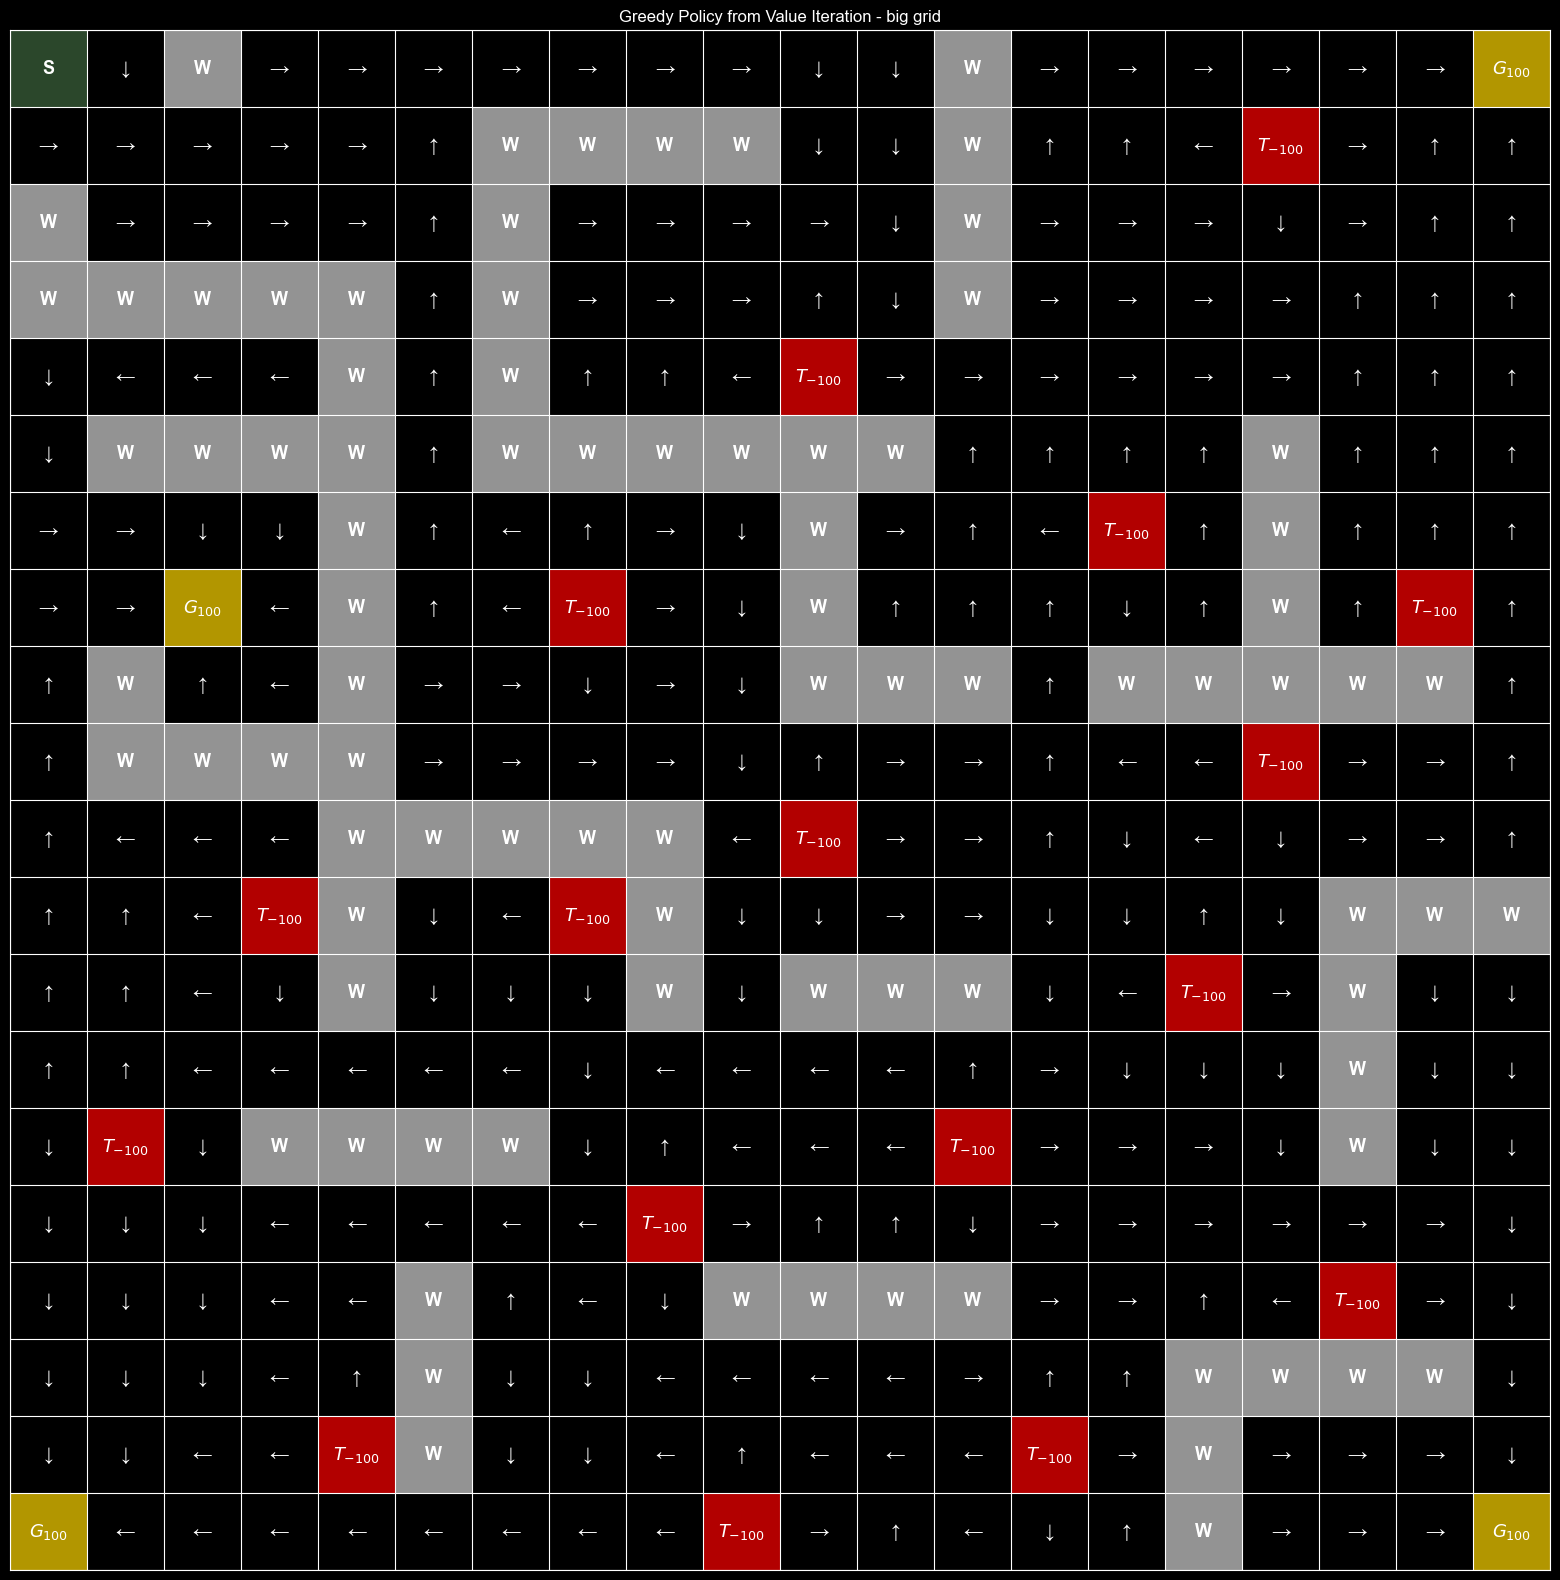

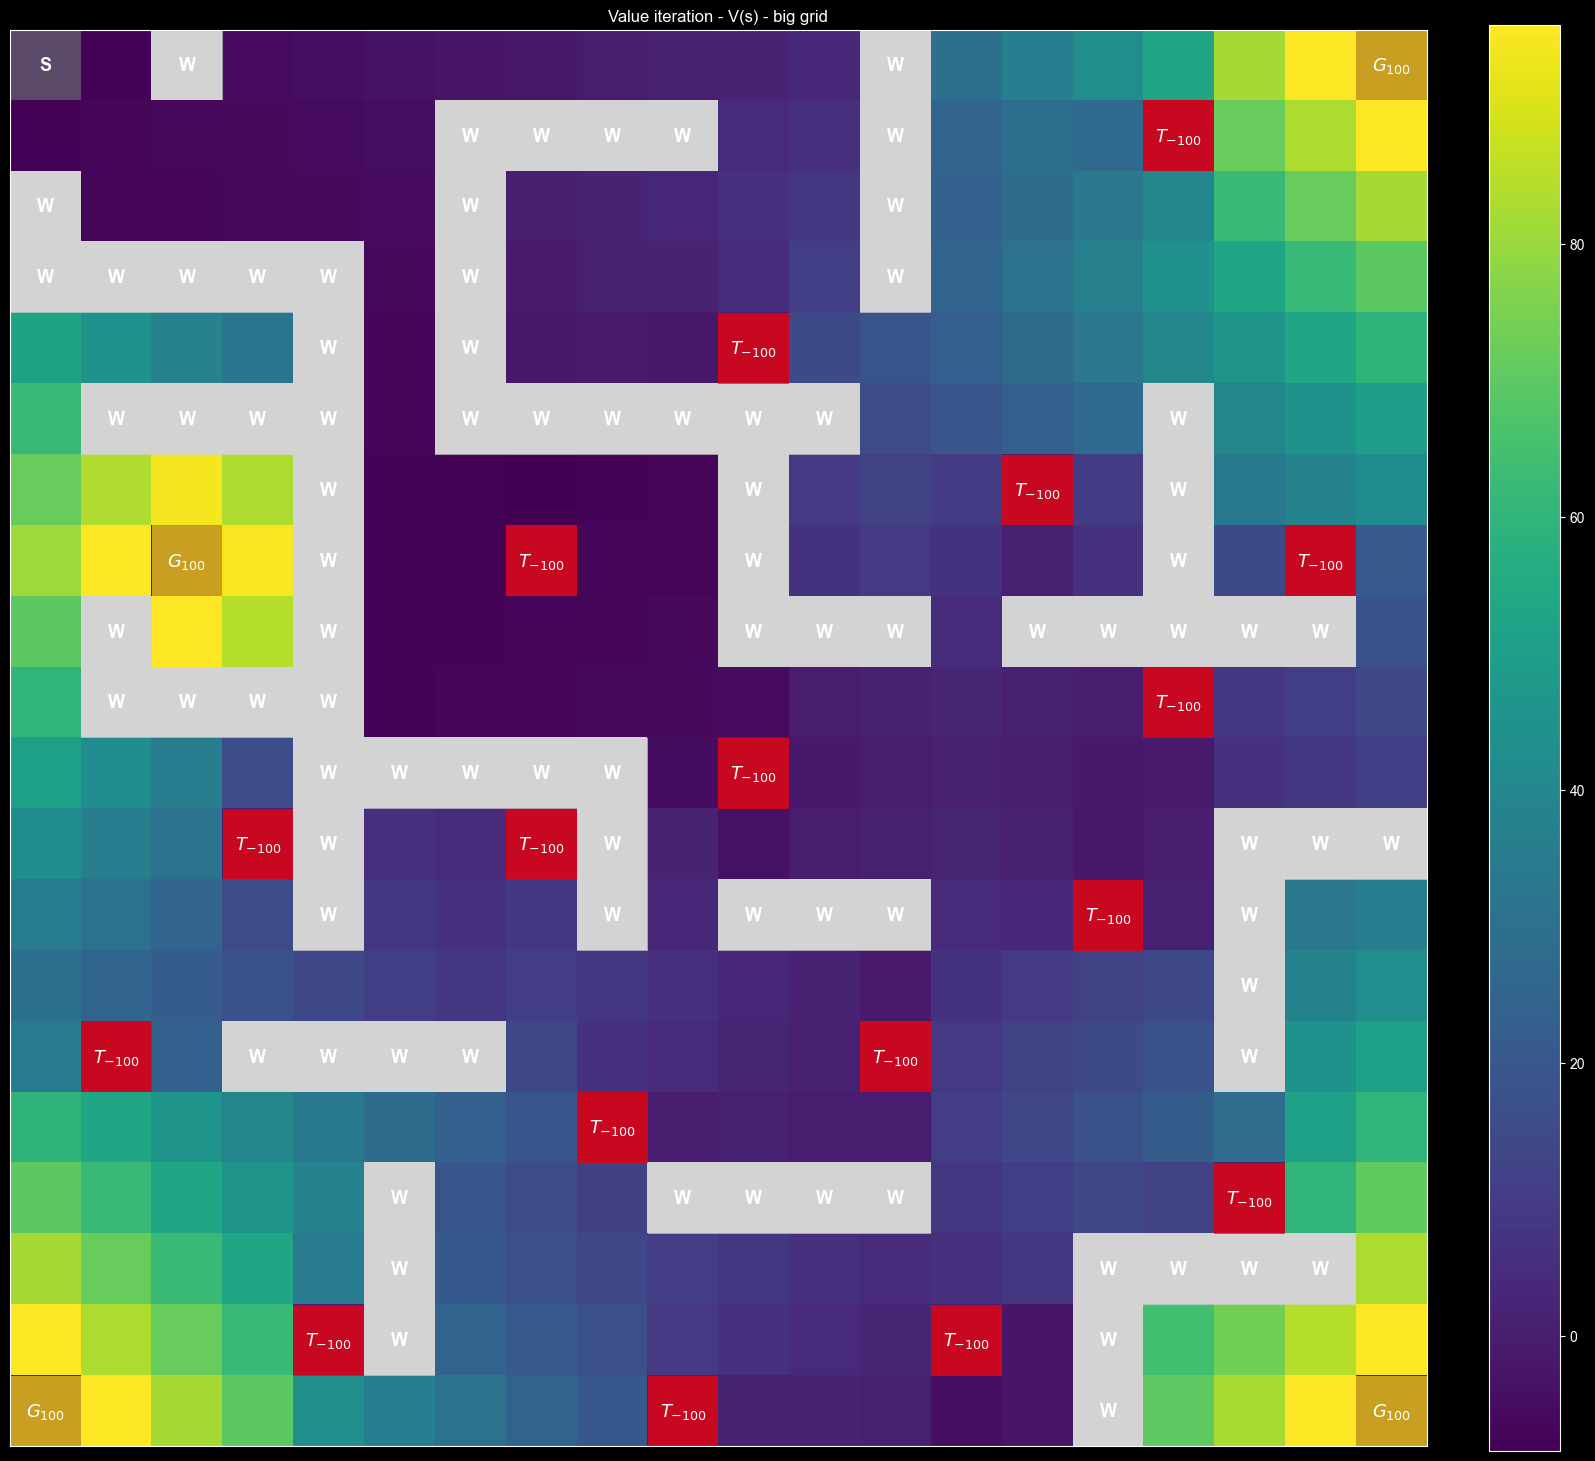

Value iteration - big grid:  {'avg_return': 63.17, 'std_return': 4.5838, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 37.83}


In [40]:
policy_plot_name = "BigGrid/policy_VI_big.png"
value_plot_name = "BigGrid/value_VI_big.png"
gif_name = "BigGrid/episode_VI_big.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Value Iteration - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Value iteration - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Value iteration - big grid: ",metrics)

# run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## QLearning

In [41]:
alpha = 0.16
epsilon = 0.1
gamma = 0.99
max_iterations = 120000

V, pi = QLearning(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

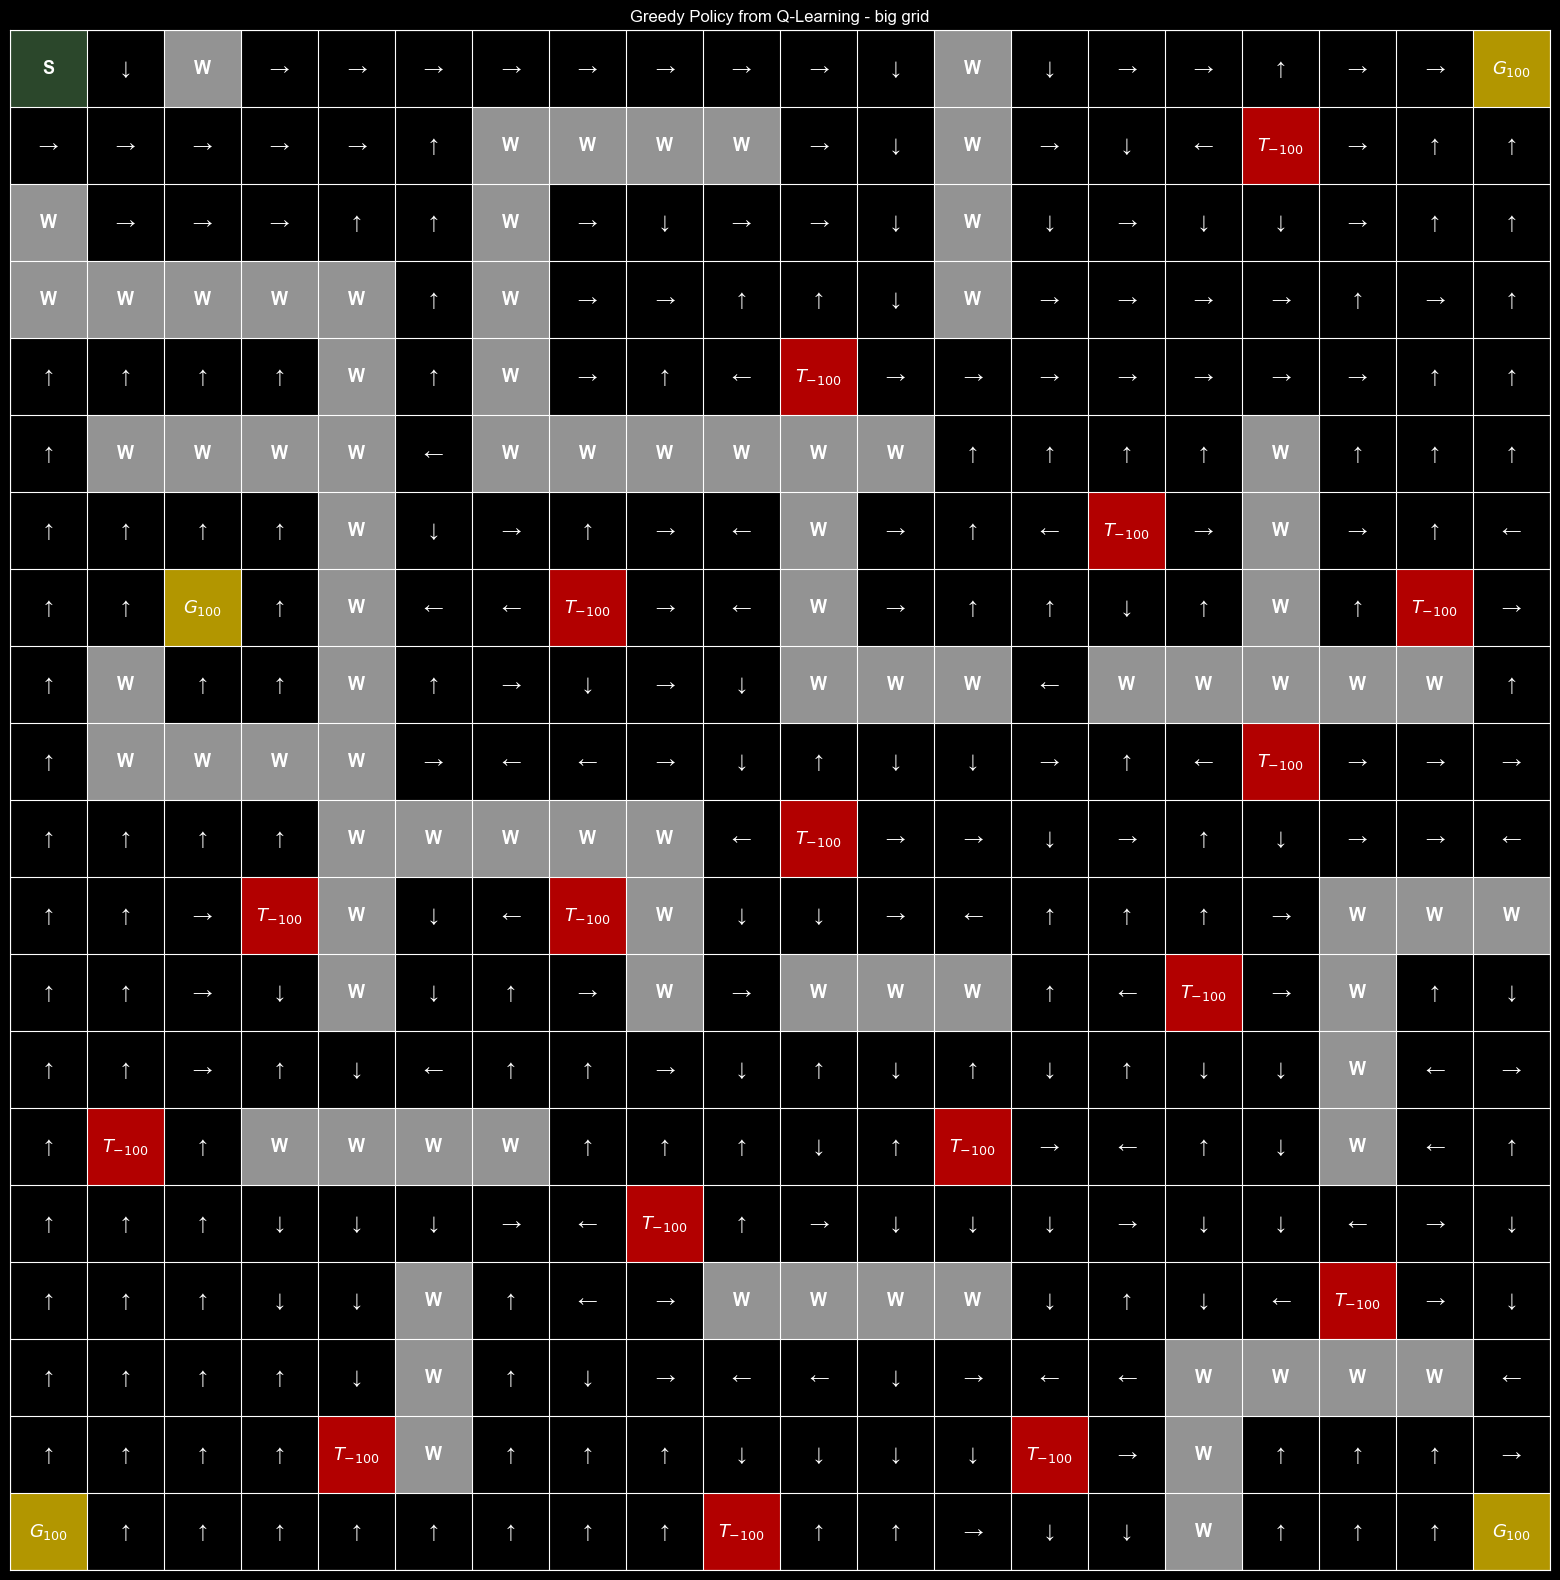

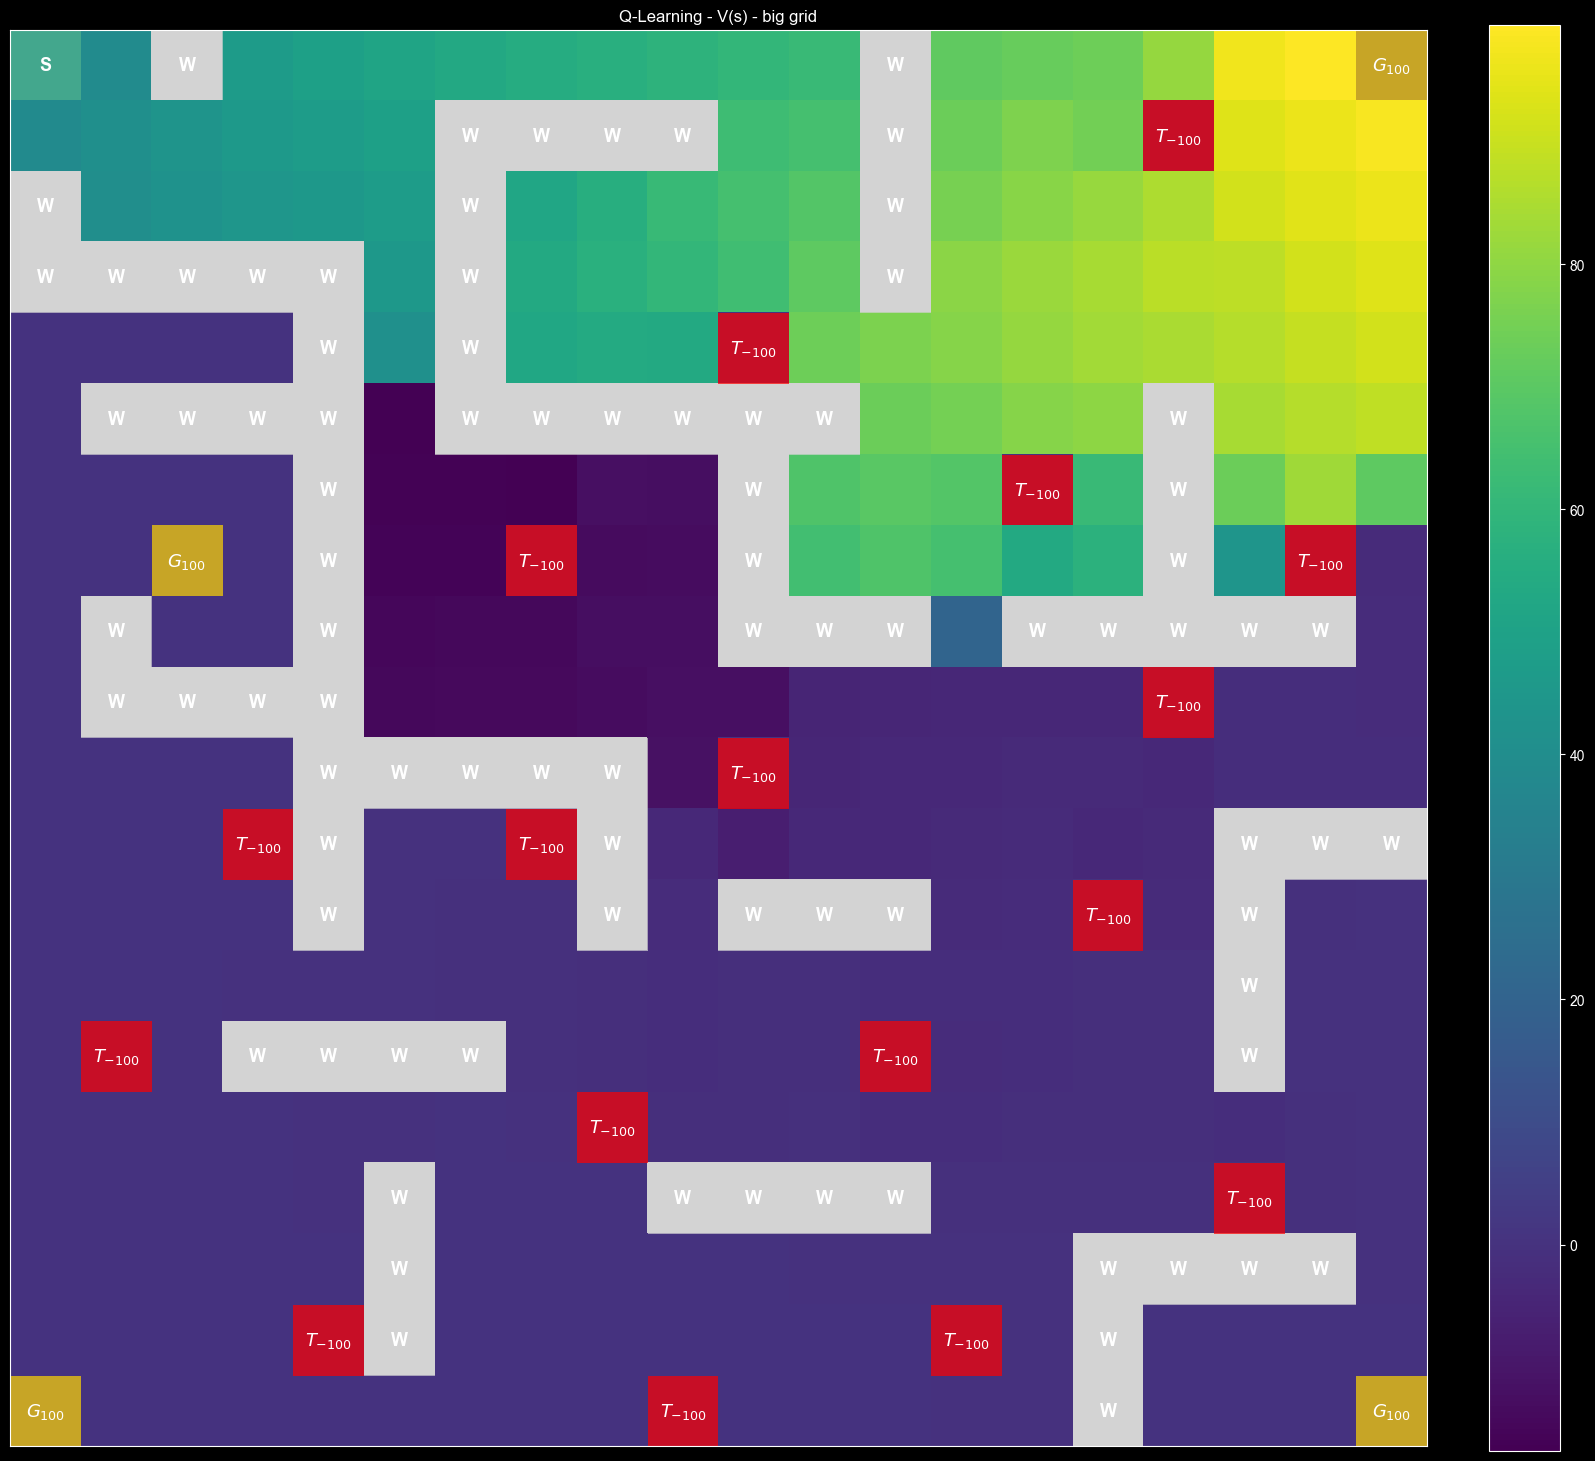

Q-Learning - big grid:  {'avg_return': 63.07, 'std_return': 4.4581, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 37.93}


In [42]:
policy_plot_name = "BigGrid/policy_QL_big.png"
value_plot_name = "BigGrid/value_QL_big.png"
gif_name = "BigGrid/episode_QL_big.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Q-Learning - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Q-Learning - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Q-Learning - big grid: ",metrics)

# run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## SARSA

In [45]:
alpha = 0.16
epsilon = 0.1
gamma = 0.99
max_iterations = 120000

V, pi = SARSA(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

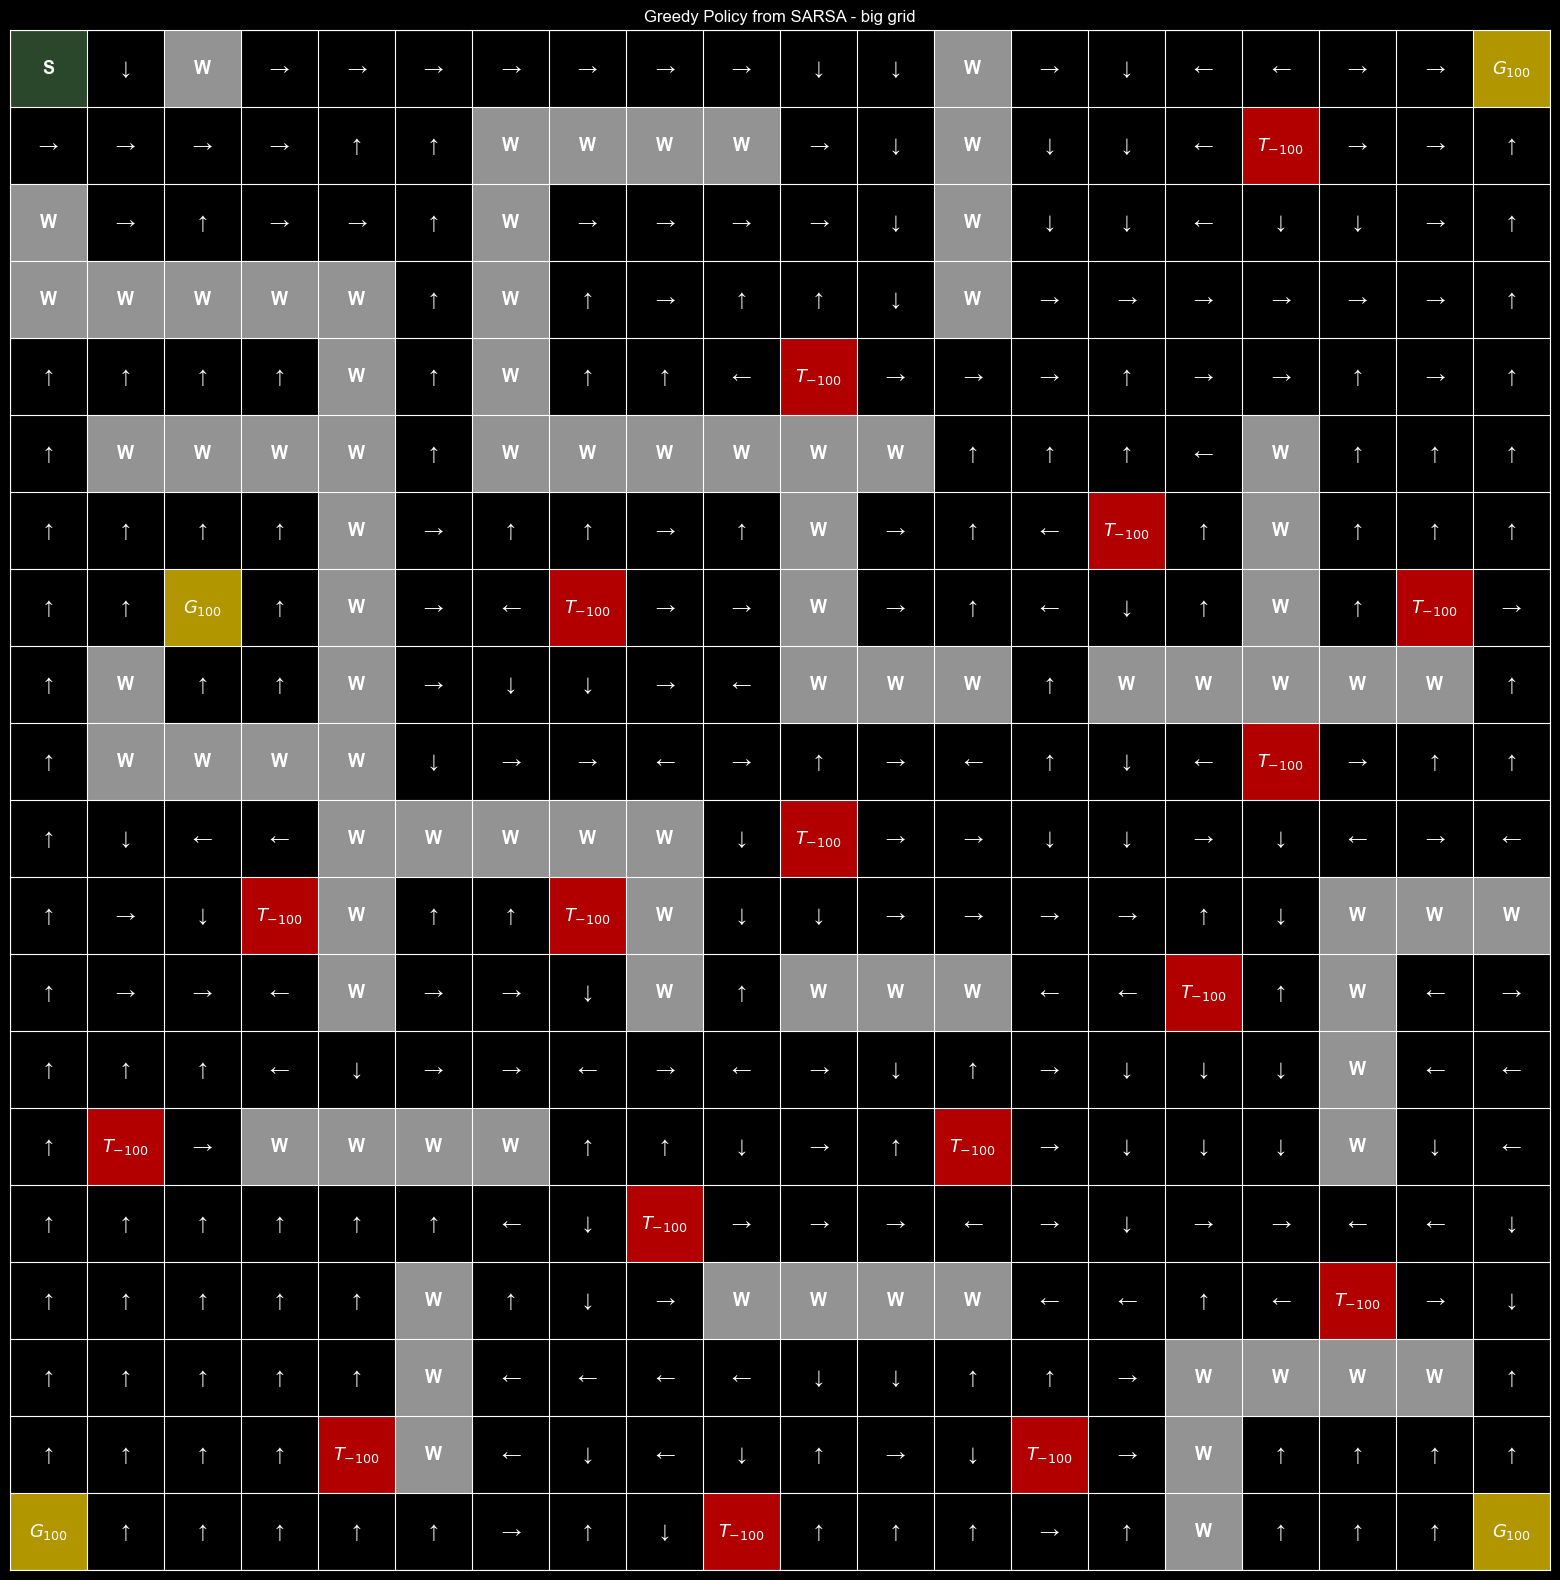

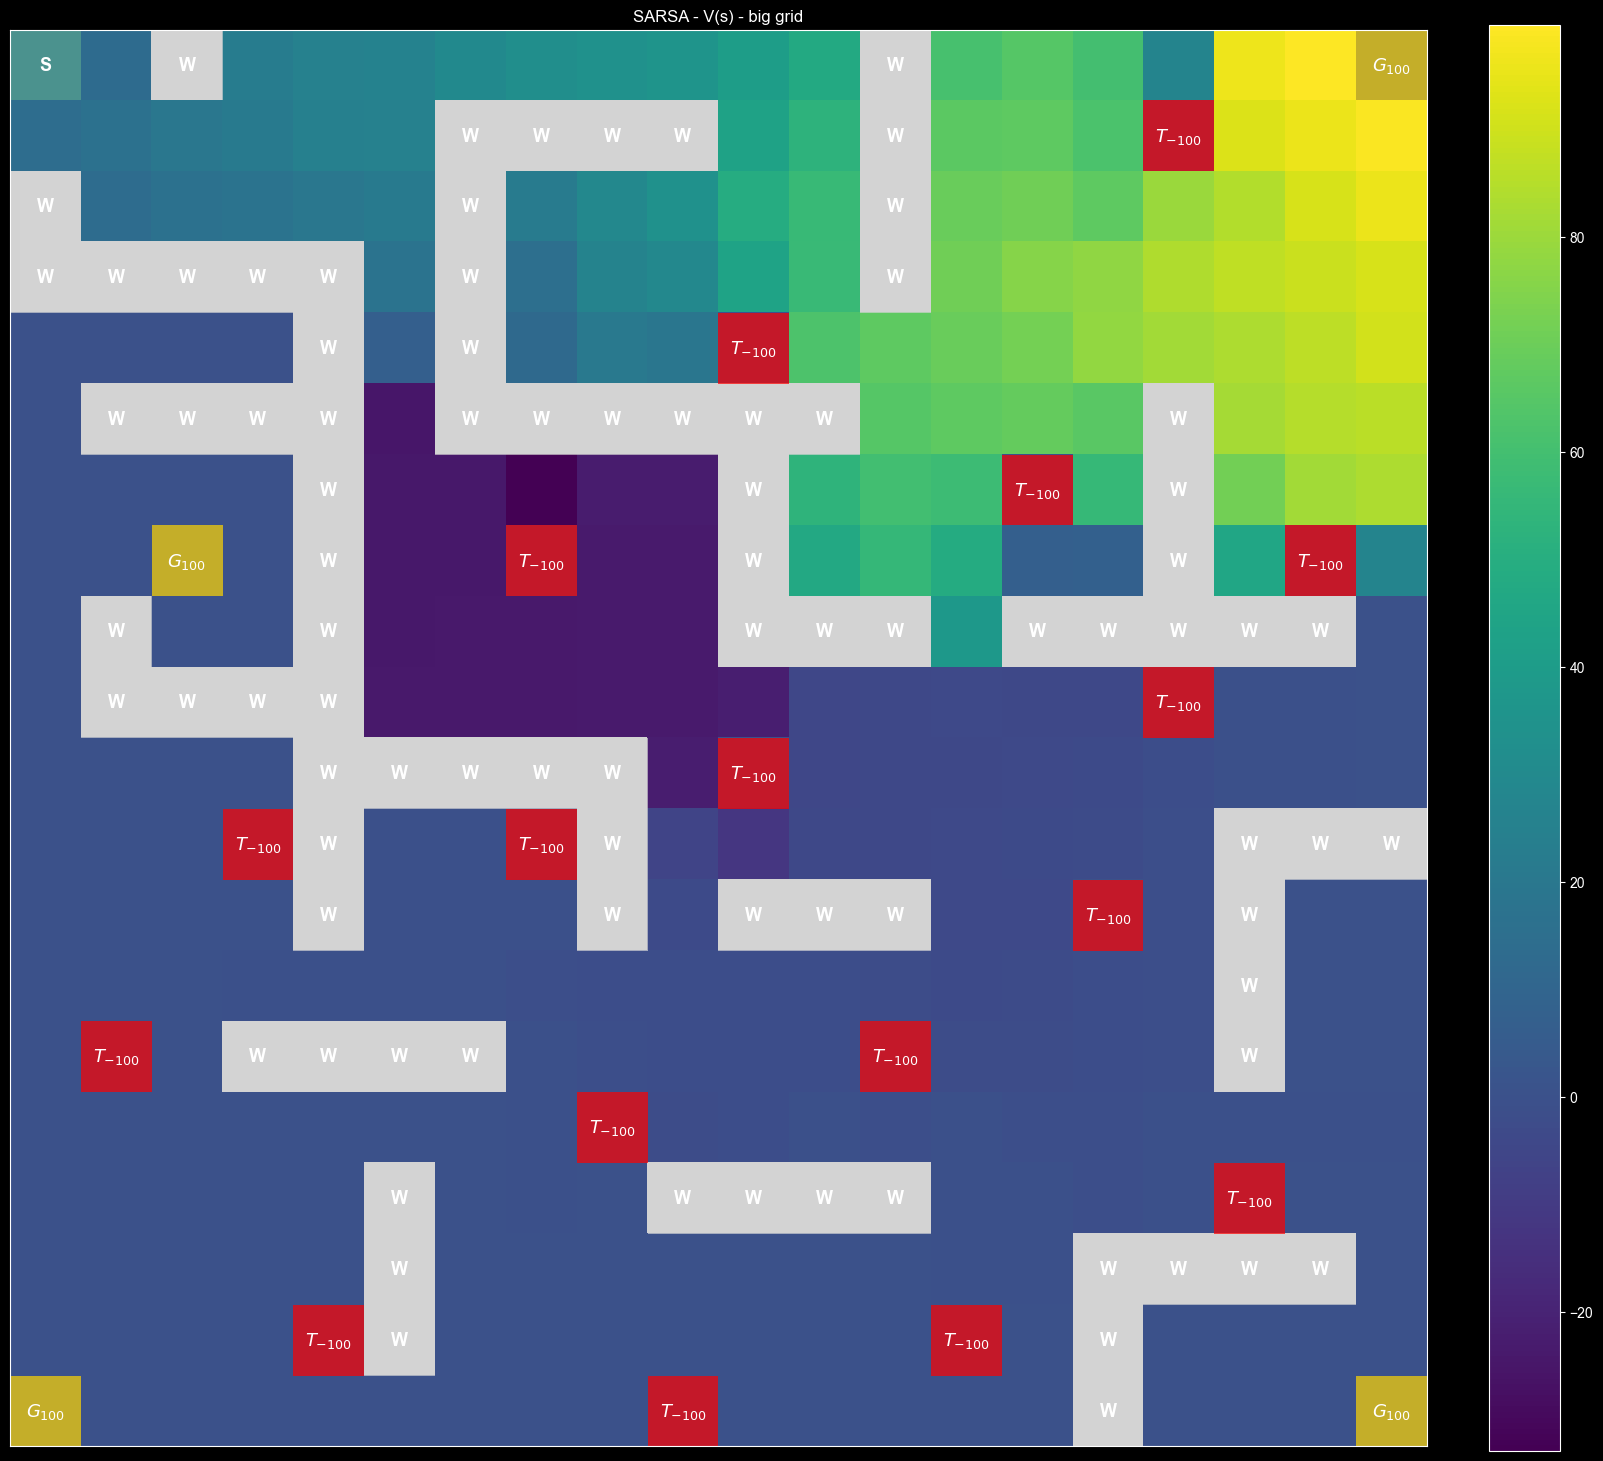

SARSA - big grid:  {'avg_return': 61.49, 'std_return': 5.5109, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 39.51}


In [46]:
policy_plot_name = "BigGrid/policy_SARSA_big.png"
value_plot_name = "BigGrid/value_SARSA_big.png"
gif_name = "BigGrid/episode_SARSA_big.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from SARSA - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="SARSA - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("SARSA - big grid: ",metrics)

# run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## Dyna-Q


In [47]:
alpha = 0.16
epsilon = 0.1
gamma = 0.99
max_iterations = 120000
n=5

V, pi = DynaQ(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations, n=n)

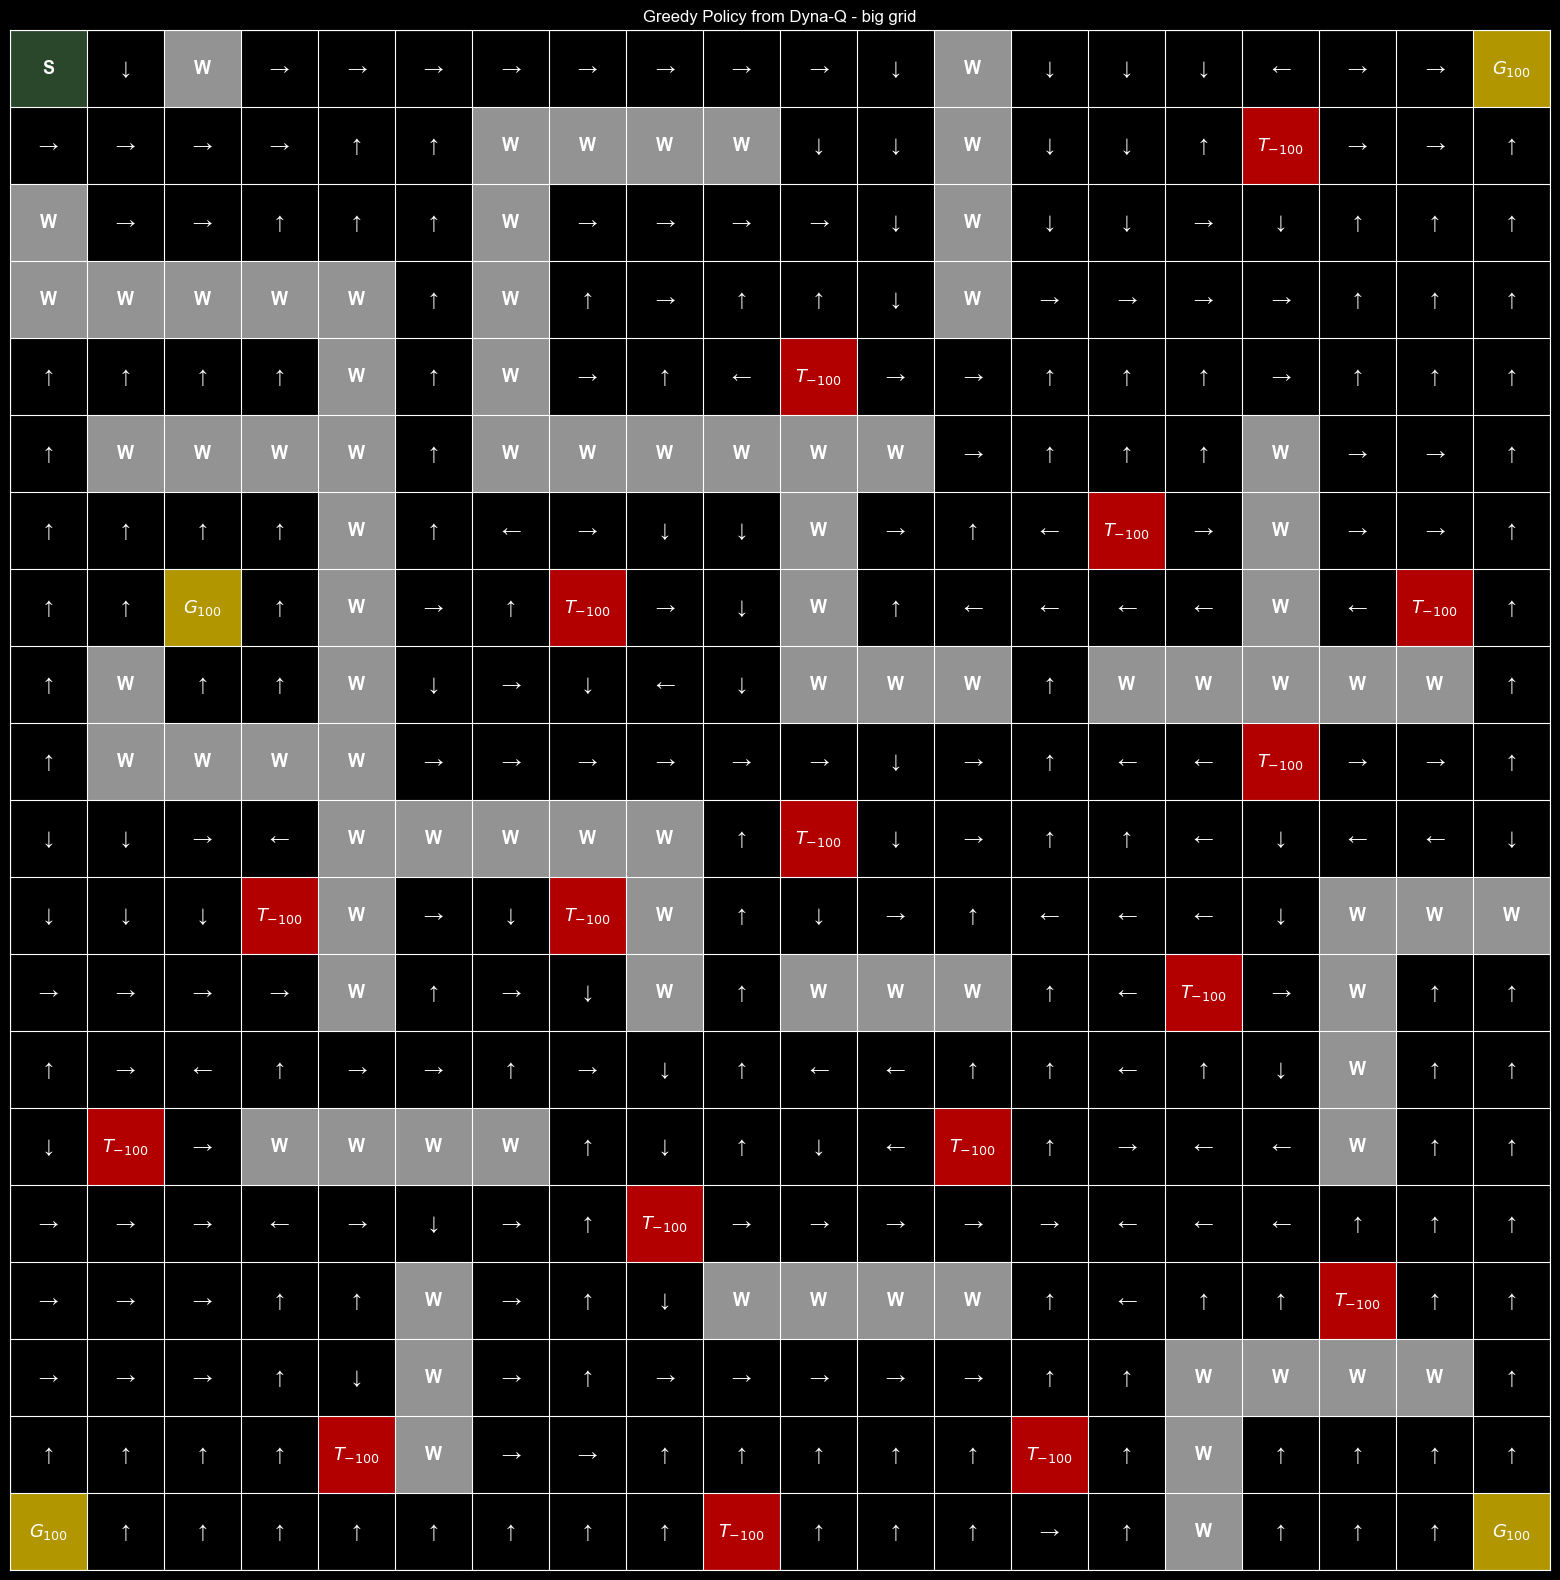

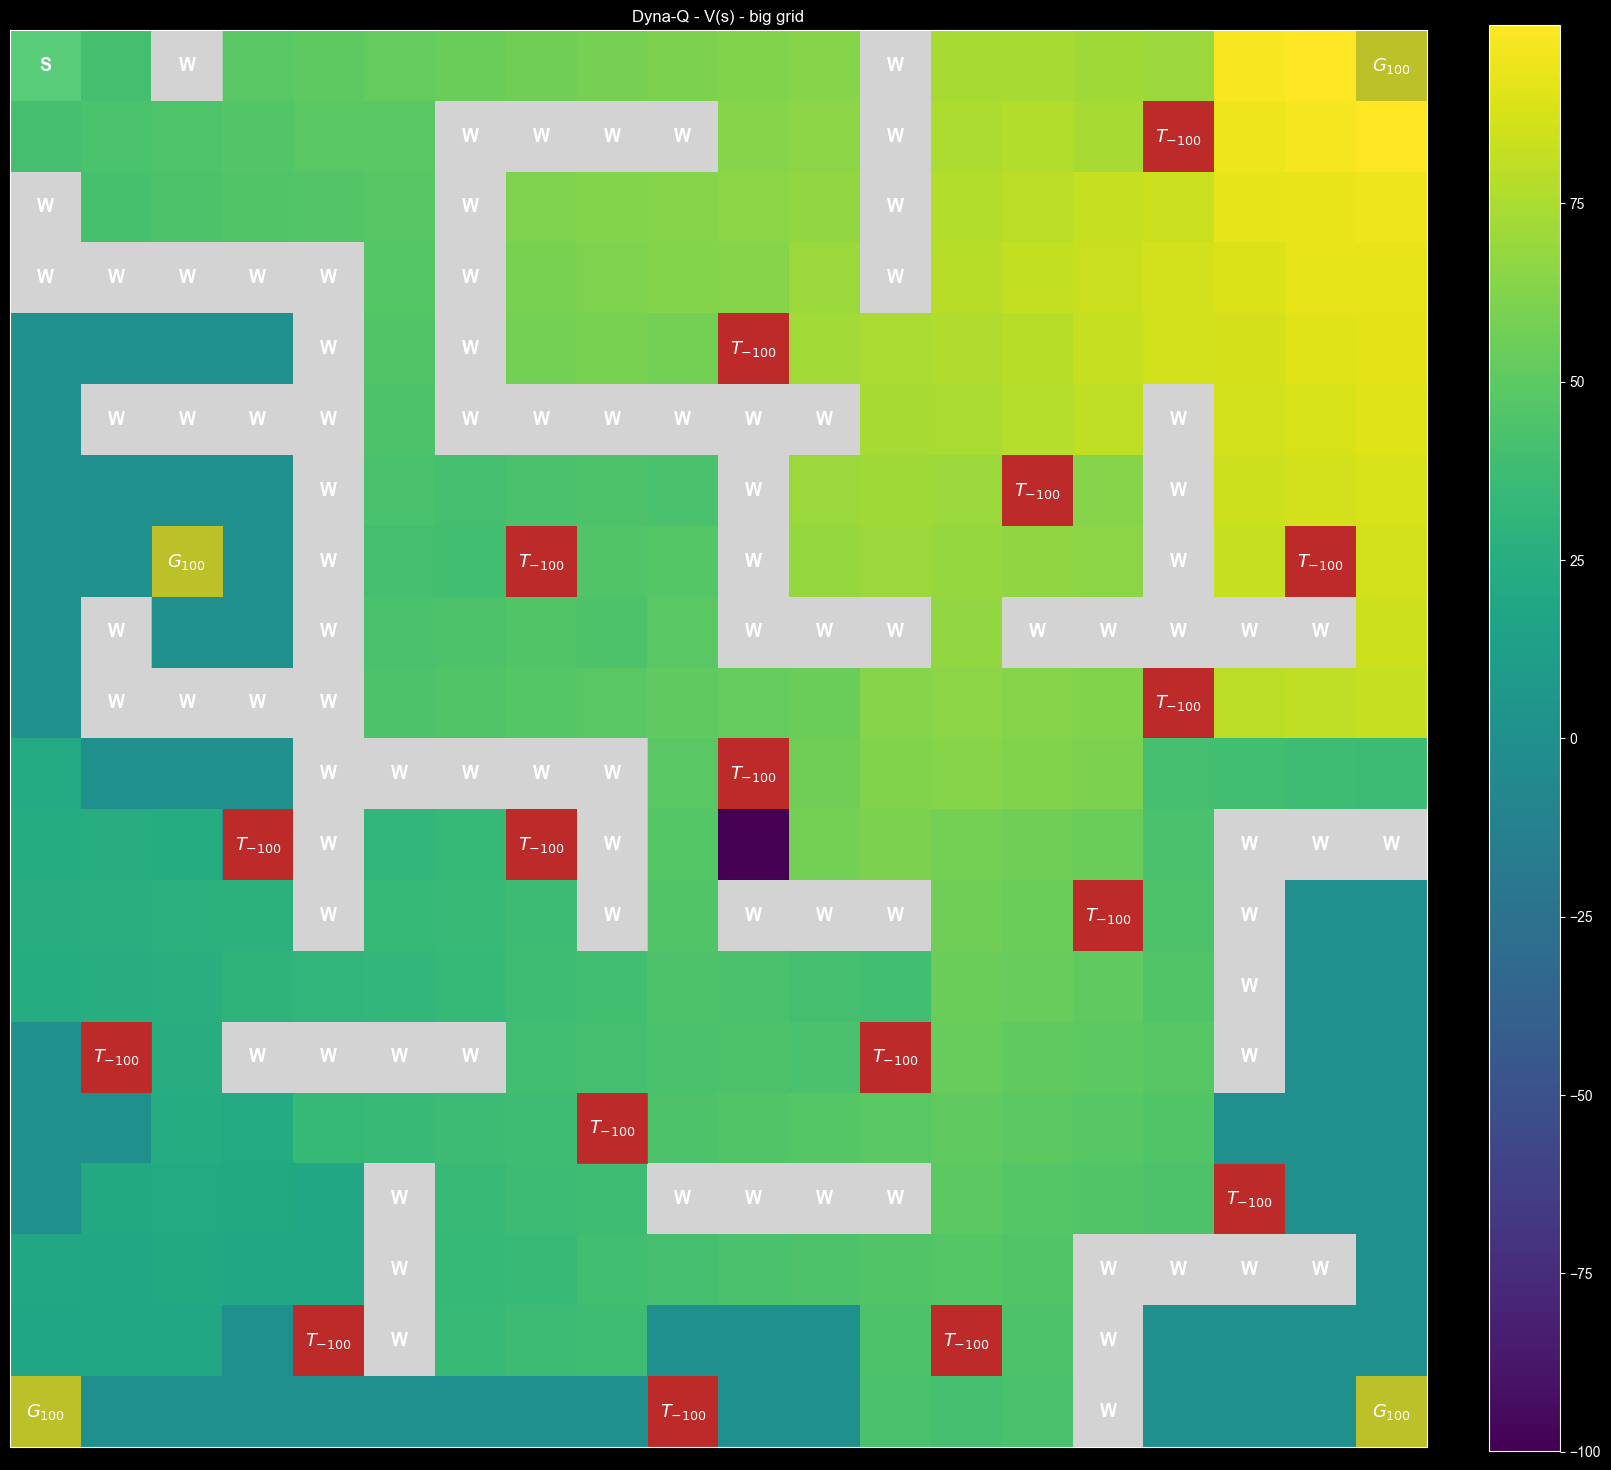

Dyna-Q - big grid:  {'avg_return': 61.36, 'std_return': 6.0844, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 39.64}


In [48]:
policy_plot_name = "BigGrid/policy_DynaQ_big.png"
value_plot_name = "BigGrid/value_DynaQ_big.png"
gif_name = "BigGrid/episode_DynaQ_big.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Dyna-Q - big grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Dyna-Q - V(s) - big grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Dyna-Q - big grid: ",metrics)

# run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# SMALL ENVIRONMENT

In [26]:
# Grid parameters
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10
walls = [(1, 2), (2, 0), (0,2),(1,5),(1,6)]
traps = [(4, 2),(2, 5)]
trap_rewards=[-100,-100]
add_goals = [(0, 6), (4, 0)]
add_goals_rewards = [10, 10]

# Evaluation parameters
max_steps_in_env = 200 # used for episodic evaluation
plot_vmin = np.min(trap_rewards)
plot_vmax = np.max(add_goals_rewards+[goal_reward])

env = ModifiedSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed,
                                walls=walls,  terminal_traps=traps, trap_rewards=trap_rewards, additional_goals=add_goals, additional_goal_rewards=add_goals_rewards)

## Value Iteration

In [27]:
# Value iteration parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-6 # stopping condition
gamma = 0.99 # discount factor
alpha = 0.15

V, pi = ValueIteration(env, max_number_iterations=max_number_iterations, gamma=gamma, threshold=threshold)

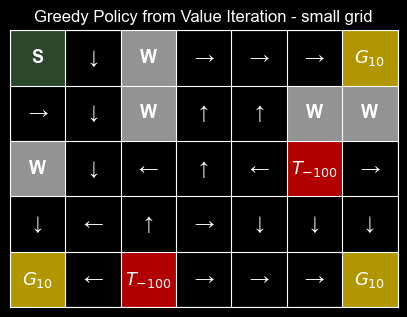

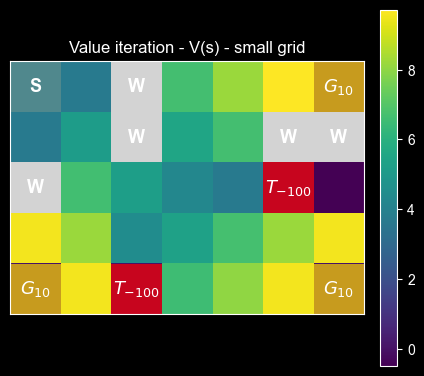

Value iteration - small grid:  {'avg_return': 2.98, 'std_return': 2.1748, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 8.02}


In [28]:
policy_plot_name = "SmallGrid/policy_VI_small.png"
value_plot_name = "SmallGrid/value_VI_small.png"
gif_name = "SmallGrid/episode_VI_small.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Value Iteration - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Value iteration - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Value iteration - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## QLearning

In [29]:
alpha = 0.13
epsilon = 0.1
gamma = 0.99
max_iterations = 5000

V, pi = QLearning(env=env, epsilon=0.1, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

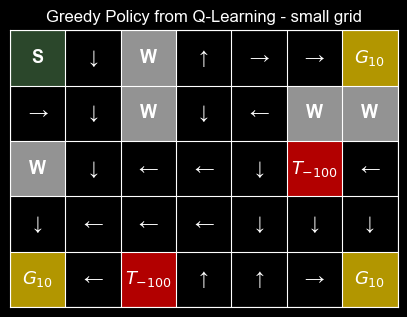

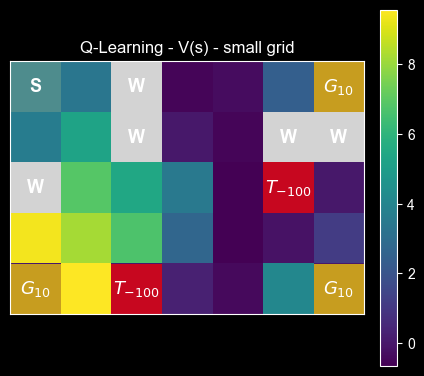

Q-Learning - small grid:  {'avg_return': 3.03, 'std_return': 2.1258, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 7.97}


In [30]:
policy_plot_name = "SmallGrid/policy_QL_small.png"
value_plot_name = "SmallGrid/value_QL_small.png"
gif_name = "SmallGrid/episode_QL_small.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Q-Learning - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Q-Learning - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Q-Learning - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## SARSA


In [31]:
alpha = 0.13
epsilon = 0.1
gamma = 0.99
max_iterations = 5000

V, pi = SARSA(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations)

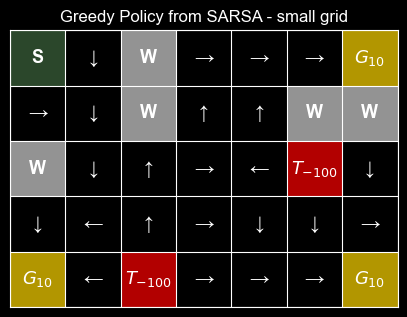

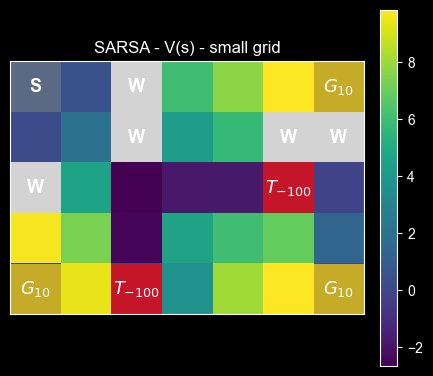

SARSA - small grid:  {'avg_return': 2.155, 'std_return': 4.3429, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 8.845}


In [32]:
policy_plot_name = "SmallGrid/policy_SARSA_small.png"
value_plot_name = "SmallGrid/value_SARSA_small.png"
gif_name = "SmallGrid/episode_SARSA_small.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from SARSA - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="SARSA - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("SARSA - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

## Dyna-Q

In [35]:
alpha = 0.13
epsilon = 0.1
gamma = 0.99
max_iterations = 5000
n=3

V, pi = DynaQ(env=env, epsilon=epsilon, gamma=gamma, alpha=alpha, max_iterations=max_iterations, n=n)

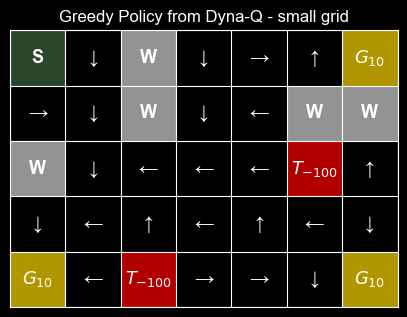

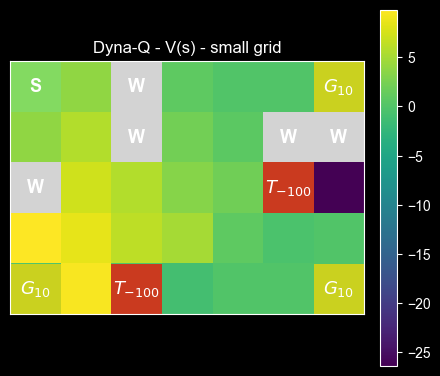

Dyna-Q - small grid:  {'avg_return': 2.98, 'std_return': 2.1748, 'success_rate': 1.0, 'trap_rate': 0.0, 'avg_steps': 8.02}


In [36]:
policy_plot_name = "SmallGrid/policy_DynaQ_small.png"
value_plot_name = "SmallGrid/value_DynaQ_small.png"
gif_name = "SmallGrid/episode_DynaQ_small.gif"
n_val_episodes = 200

env.reset()

plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy from Dyna-Q - small grid")
plot_value_heatmap(env, V, filename=value_plot_name, title="Dyna-Q - V(s) - small grid", vmin=plot_vmin, vmax=plot_vmax)
plt.close("all")

metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print("Dyna-Q - small grid: ",metrics)

run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# COMPARISON and PARAMETERS EXPERIMENTS